In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns


In [2]:
data=pd.read_csv('/content/CO2_emission.csv')
data

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
0,2021,Acura,ILX,Compact,2.4,4,AM8,9.9,7.0,8.6,199,3
1,2021,Acura,NSX,Two-seater,3.5,6,AM9,11.1,10.8,11.0,256,3
2,2021,Acura,RDX SH-AWD,SUV: Small,2.0,4,AS10,11.0,8.6,9.9,232,6
3,2021,Acura,RDX SH-AWD A-SPEC,SUV: Small,2.0,4,AS10,11.3,9.1,10.3,242,6
4,2021,Acura,TLX SH-AWD,Compact,2.0,4,AS10,11.2,8.0,9.8,230,7
...,...,...,...,...,...,...,...,...,...,...,...,...
930,2021,Volvo,XC40 T5 AWD,SUV: Small,2.0,4,AS8,10.7,7.7,9.4,219,5
931,2021,Volvo,XC60 T5 AWD,SUV: Small,2.0,4,AS8,11.1,8.3,9.9,230,5
932,2021,Volvo,XC60 T6 AWD,SUV: Small,2.0,4,AS8,11.7,8.6,10.3,240,7
933,2021,Volvo,XC90 T5 AWD,SUV: Standard,2.0,4,AS8,11.5,8.4,10.1,236,5


In [3]:
data.isnull().sum()

,0
Model_Year,0
Make,0
Model,0
Vehicle_Class,0
Engine_Size,0
Cylinders,0
Transmission,0
Fuel_Consumption_in_City(L/100 km),0
Fuel_Consumption_in_City_Hwy(L/100 km),0
Fuel_Consumption_comb(L/100km),0


In [4]:
data.dtypes

,0
Model_Year,int64
Make,object
Model,object
Vehicle_Class,object
Engine_Size,float64
Cylinders,int64
Transmission,object
Fuel_Consumption_in_City(L/100 km),float64
Fuel_Consumption_in_City_Hwy(L/100 km),float64
Fuel_Consumption_comb(L/100km),float64


In [5]:
data.describe()

,Model_Year,Engine_Size,Cylinders,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),CO2_Emissions,Smog_Level
count,935.0,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000,935.000000
mean,2021.0,3.214866,5.716578,12.498610,9.306203,11.060214,258.529412,4.726203
std,0.0,1.388513,1.977359,3.487271,2.215819,2.867028,64.442768,1.712127
min,2021.0,1.000000,3.000000,4.000000,3.900000,4.000000,94.000000,1.000000
25%,2021.0,2.000000,4.000000,10.100000,7.700000,9.100000,213.000000,3.000000
50%,2021.0,3.000000,6.000000,12.000000,9.000000,10.700000,255.000000,5.000000
75%,2021.0,4.000000,8.000000,14.800000,10.800000,13.100000,303.500000,6.000000
max,2021.0,8.000000,16.000000,30.300000,20.900000,26.100000,608.000000,7.000000


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le=LabelEncoder()

In [8]:
data['Make']=le.fit_transform(data['Make'])
data['Model']=le.fit_transform(data['Model'])
data['Vehicle_Class']=le.fit_transform(data['Vehicle_Class'])
data['Transmission']=le.fit_transform(data['Transmission'])



In [9]:
data['Smog_Level'].unique()

array([3, 6, 7, 5, 1])

In [10]:
data1=data.drop('CO2_Emissions',axis=1)
data1

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),Smog_Level
0,2021,0,355,0,2.4,4,6,9.9,7.0,8.6,3
1,2021,0,438,13,3.5,6,7,11.1,10.8,11.0,3
2,2021,0,506,7,2.0,4,8,11.0,8.6,9.9,6
3,2021,0,507,7,2.0,4,8,11.3,9.1,10.3,6
4,2021,0,604,0,2.0,4,8,11.2,8.0,9.8,7
...,...,...,...,...,...,...,...,...,...,...,...
930,2021,37,683,7,2.0,4,12,10.7,7.7,9.4,5
931,2021,37,684,7,2.0,4,12,11.1,8.3,9.9,5
932,2021,37,685,7,2.0,4,12,11.7,8.6,10.3,7
933,2021,37,686,8,2.0,4,12,11.5,8.4,10.1,5


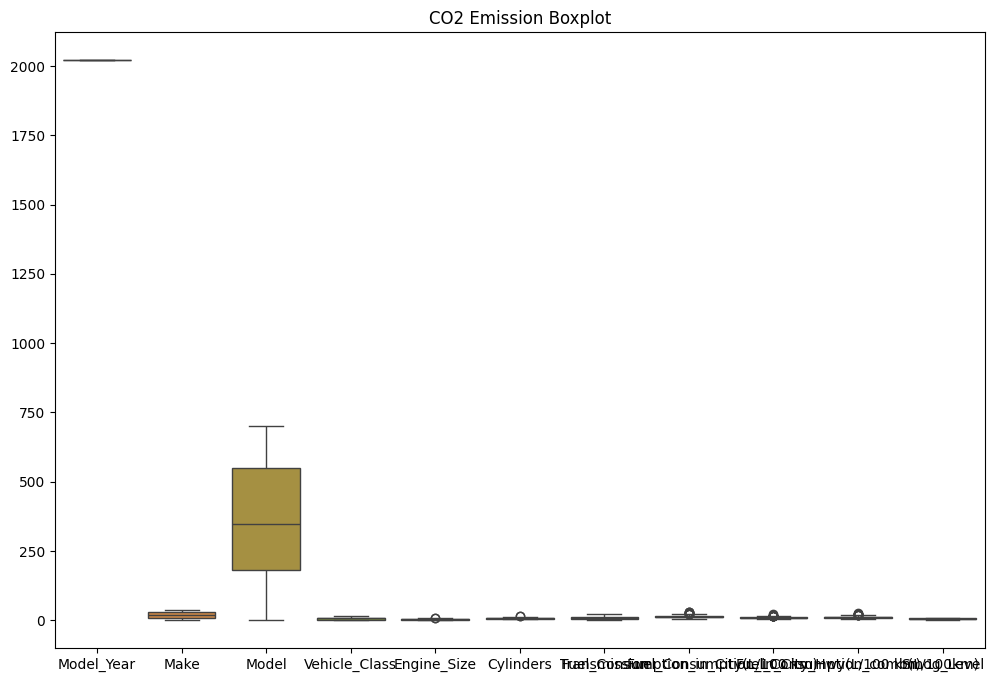

In [11]:
plt.figure(figsize=(12,8))
sns.boxplot(data=data1)
plt.title('CO2 Emission Boxplot')
plt.show()

In [12]:
Q1=data1.quantile(0.25)
Q3=data1.quantile(0.75)
IQR=Q3-Q1
IQR

,0
Model_Year,0.0
Make,19.0
Model,366.5
Vehicle_Class,6.0
Engine_Size,2.0
Cylinders,4.0
Transmission,9.0
Fuel_Consumption_in_City(L/100 km),4.7
Fuel_Consumption_in_City_Hwy(L/100 km),3.1
Fuel_Consumption_comb(L/100km),4.0


In [13]:
lower_bound=Q1-1.5 * IQR
upper_bound=Q3+1.5 * IQR

In [14]:
lower_bound

,0
Model_Year,2021.00
Make,-19.50
Model,-368.25
Vehicle_Class,-7.00
Engine_Size,-1.00
Cylinders,-2.00
Transmission,-10.50
Fuel_Consumption_in_City(L/100 km),3.05
Fuel_Consumption_in_City_Hwy(L/100 km),3.05
Fuel_Consumption_comb(L/100km),3.10


In [15]:
upper_bound

,0
Model_Year,2021.00
Make,56.50
Model,1097.75
Vehicle_Class,17.00
Engine_Size,7.00
Cylinders,14.00
Transmission,25.50
Fuel_Consumption_in_City(L/100 km),21.85
Fuel_Consumption_in_City_Hwy(L/100 km),15.45
Fuel_Consumption_comb(L/100km),19.10


In [16]:
outliers=(data1 < lower_bound) | (data1 > upper_bound)
outliers


,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),Smog_Level
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
930,False,False,False,False,False,False,False,False,False,False,False
931,False,False,False,False,False,False,False,False,False,False,False
932,False,False,False,False,False,False,False,False,False,False,False
933,False,False,False,False,False,False,False,False,False,False,False


In [17]:
df_cleaned=data1[~outliers.any(axis=1)]

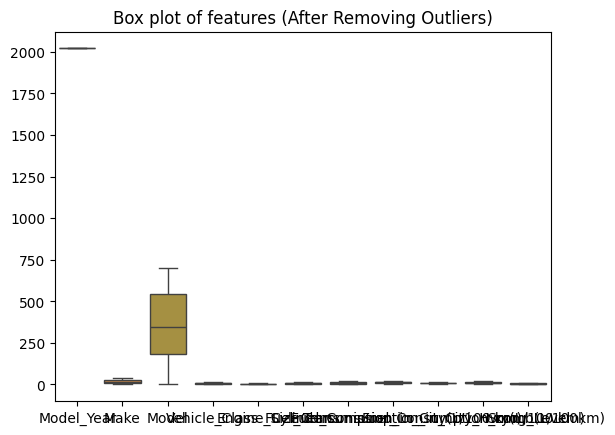

In [18]:
plt.Figure(figsize=(12,6))
sns.boxplot(data=df_cleaned)
plt.title('Box plot of features (After Removing Outliers)')
plt.show()

In [19]:
x=data.drop('CO2_Emissions',axis=1)
x

,Model_Year,Make,Model,Vehicle_Class,Engine_Size,Cylinders,Transmission,Fuel_Consumption_in_City(L/100 km),Fuel_Consumption_in_City_Hwy(L/100 km),Fuel_Consumption_comb(L/100km),Smog_Level
0,2021,0,355,0,2.4,4,6,9.9,7.0,8.6,3
1,2021,0,438,13,3.5,6,7,11.1,10.8,11.0,3
2,2021,0,506,7,2.0,4,8,11.0,8.6,9.9,6
3,2021,0,507,7,2.0,4,8,11.3,9.1,10.3,6
4,2021,0,604,0,2.0,4,8,11.2,8.0,9.8,7
...,...,...,...,...,...,...,...,...,...,...,...
930,2021,37,683,7,2.0,4,12,10.7,7.7,9.4,5
931,2021,37,684,7,2.0,4,12,11.1,8.3,9.9,5
932,2021,37,685,7,2.0,4,12,11.7,8.6,10.3,7
933,2021,37,686,8,2.0,4,12,11.5,8.4,10.1,5


In [20]:
y=data['CO2_Emissions']
y

,CO2_Emissions
0,199
1,256
2,232
3,242
4,230
...,...
930,219
931,230
932,240
933,236


In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=scaler.fit_transform(df_cleaned)
X

array([[ 0.        , -1.80634202,  0.00346304, ..., -1.07753756,
        -0.88616132, -1.05542697],
       [ 0.        , -1.80634202,  0.41136004, ...,  0.78623923,
         0.03344947, -1.05542697],
       [ 0.        , -1.80634202,  0.74554071, ..., -0.29278944,
        -0.38803881,  0.73142641],
       ...,
       [ 0.        ,  1.72539916,  1.62522219, ..., -0.29278944,
        -0.23477034,  1.3270442 ],
       [ 0.        ,  1.72539916,  1.63013661, ..., -0.39088295,
        -0.31140458,  0.13580862],
       [ 0.        ,  1.72539916,  1.63505103, ..., -0.3418362 ,
        -0.15813611,  1.3270442 ]])

array([[ 0.        , -1.80634202,  0.00346304, ..., -1.07753756,
        -0.88616132, -1.05542697],
       [ 0.        , -1.80634202,  0.41136004, ...,  0.78623923,
         0.03344947, -1.05542697],
       [ 0.        , -1.80634202,  0.74554071, ..., -0.29278944,
        -0.38803881,  0.73142641],
       ...,
       [ 0.        ,  1.72539916,  1.62522219, ..., -0.29278944,
        -0.23477034,  1.3270442 ],
       [ 0.        ,  1.72539916,  1.63013661, ..., -0.39088295,
        -0.31140458,  0.13580862],
       [ 0.        ,  1.72539916,  1.63505103, ..., -0.3418362 ,
        -0.15813611,  1.3270442 ]])

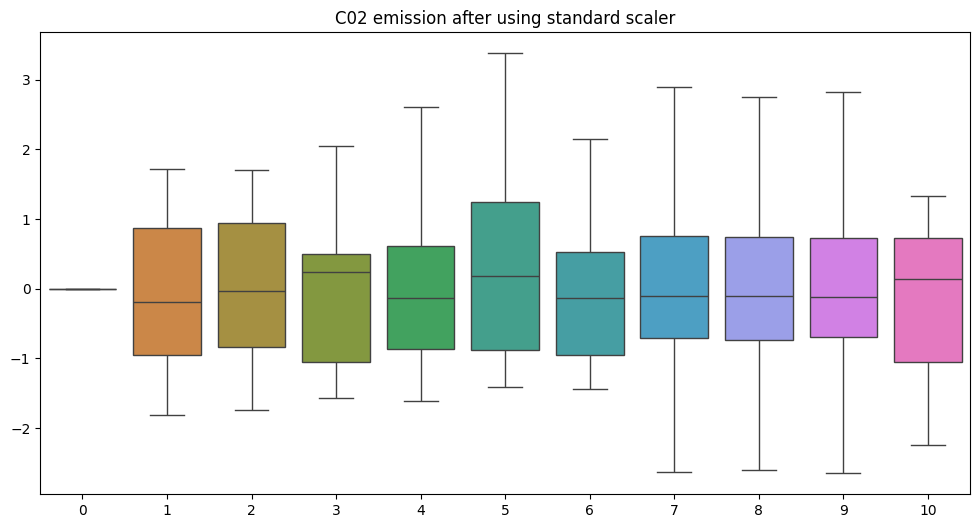

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.title('C02 emission after using standard scaler')
plt.show()

In [23]:
y = y[~outliers.any(axis=1)]
train_x,test_x,train_y,test_y=train_test_split(X,y,test_size=0.25,random_state=42)

In [24]:
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.simplefilter('ignore')

In [25]:
model_params={
    'svm':{
        'model':SVC(gamma='auto'),
        'params':{
            'C':[1,10,20],
            'kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model':RandomForestRegressor(),
        'params':{
            'n_estimators':[50,150,200]
        }
    },
    'LinearRegression':{
        'model':LinearRegression(),
        'params':{}
    },
    'kneighbors':{
        'model':KNeighborsRegressor(),
        'params':{
            'n_neighbors':[3,5,10]
        }
    },

    'decision_tree':{
        'model':DecisionTreeRegressor(),
        'params':{
            'max_depth':[1,3,5]
        }
    },

    'XGBoost':{
        'model':XGBRegressor(),
        'params':{
            'n_estimators':[50,150,200],
            'learning_rate':[0.2,0.5,1],
            'max_depth':[1,3,5]

        }
    }
}

In [26]:
import joblib
scores=[]

best_score = -float('inf')
best_model = None
best_model_name = None

models=['svm','random_forest','LinearRegression','XGBoost','kneighbors','decision_tree']
for model_name in models:
  mp_models=model_params[model_name]['model']
  mp_params=model_params[model_name]['params']

  gds=GridSearchCV(mp_models,mp_params,cv=5,return_train_score=True)
  gds.fit(train_x,train_y)

  scores.append({
      'model':model_name,
      'best_score':gds.best_score_,
      'best_params':gds.best_params_
  })
  if gds.best_score_ > best_score:
        best_score = gds.best_score_
        best_model = gds.best_estimator_
        best_model_name = model_name

# Save best model
joblib.dump(best_model, f'{best_model_name}.pkl')

print(f"{best_model_name} saved successfully")

df=pd.DataFrame(scores)
df

XGBoost saved successfully


,model,best_score,best_params
0,svm,0.220290,"{'C': 20, 'kernel': 'linear'}"
1,random_forest,0.974579,{'n_estimators': 200}
2,LinearRegression,0.970980,{}
3,XGBoost,0.979096,"{'learning_rate': 0.2, 'max_depth': 3, 'n_esti..."
4,kneighbors,0.941985,{'n_neighbors': 10}
5,decision_tree,0.959792,{'max_depth': 5}


In [27]:
xgb_model=XGBRegressor(max_depth=3,learning_rate=0.2,n_estimators=50)

In [28]:
xgb_model.fit(train_x,train_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.2, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=50,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
xgb_model.score(train_x,train_y)

0.9965474605560303

In [30]:
xgb_model.score(test_x,test_y)

0.9753077030181885

In [31]:
y_pred=xgb_model.predict(test_x)
y_pred

array([212.86716 , 319.8671  , 263.8302  , 239.84848 , 194.4815  ,
       220.72534 , 288.13742 , 213.78198 , 322.65115 , 215.54636 ,
       325.58575 , 196.59428 , 352.79855 , 182.0118  , 288.39417 ,
       216.2982  , 377.9253  , 229.7313  , 330.55246 , 156.67245 ,
       343.74844 , 246.50516 , 214.44511 , 323.3348  , 219.7158  ,
       214.08684 , 199.2651  , 268.96066 , 166.14384 , 272.1768  ,
       360.92267 , 216.17747 , 288.87772 , 321.26276 , 106.523384,
       273.5706  , 321.98193 , 255.44475 , 239.71848 , 252.1908  ,
       209.48515 , 241.16011 , 254.94916 , 308.50424 , 355.74033 ,
       274.2437  , 224.8541  , 204.20503 , 240.41339 , 189.51515 ,
       240.18536 , 223.60678 , 250.23833 , 128.09027 , 267.02133 ,
       274.66934 , 280.9905  , 349.19464 , 192.802   , 264.58905 ,
       308.00092 , 284.67148 , 252.68994 , 207.20071 , 230.5254  ,
       195.73299 , 222.47554 , 216.61057 , 176.94234 , 322.0218  ,
       288.39417 , 318.64026 , 166.61064 , 360.33142 , 166.578

In [32]:
pd_table=pd.DataFrame({'true y value':test_y,'predicted y value':y_pred})
pd_table

,true y value,predicted y value
323,217,212.867157
384,321,319.867096
546,279,263.830200
300,259,239.848480
539,195,194.481506
...,...,...
670,330,331.703674
303,287,282.350769
834,408,389.441193
265,331,327.443024


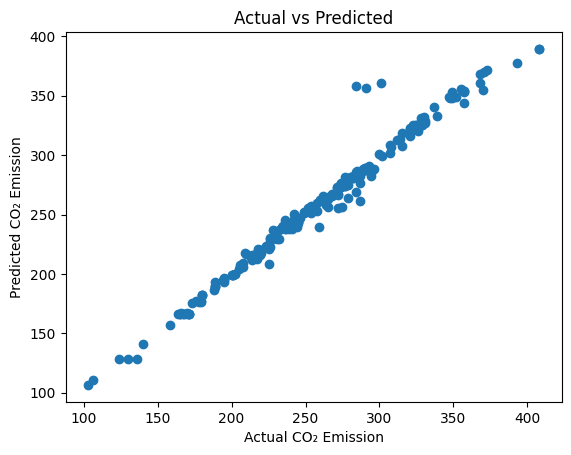

In [33]:
import matplotlib.pyplot as plt

plt.scatter(test_y, y_pred)
plt.xlabel("Actual CO₂ Emission")
plt.ylabel("Predicted CO₂ Emission")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
new_data_raw = [[2,0.1,0.5,0.8,1,0.4,0.1,6.4,1,3, 5]] 


scaled_new_data = scaler.transform(new_data_raw)

prediction = xgb_model.predict(scaled_new_data)
print("Predicted CO₂ Emission:", prediction[0])

Predicted CO₂ Emission: 108.292694
